**Kasus 3 (Data Text)**

Import Library, Seed, & Load Data

In [1]:
# TAHAP 1: PERSIAPAN DATA & IMPORT LIBRARY


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
import nltk
from nltk.corpus import stopwords
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Mengatur Seed agar hasil bisa direproduksi (Syarat Reproducibility Rubrik)
np.random.seed(42)
tf.random.set_seed(42)

# Download stopwords dari NLTK untuk pembersihan teks
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# 1. Load Data (Menggunakan raw link publik agar praktis dan reproducibility terjamin)
url = 'https://raw.githubusercontent.com/laxmimerit/twitter-disaster-prediction-dataset/master/train.csv'
df = pd.read_csv(url)

print("Dataset Disaster Tweets berhasil dimuat!")
display(df.head(3))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Dataset Disaster Tweets berhasil dimuat!


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1


Eksplorasi Data (EDA)

/tmp/ipykernel_2438/2961415389.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set2')


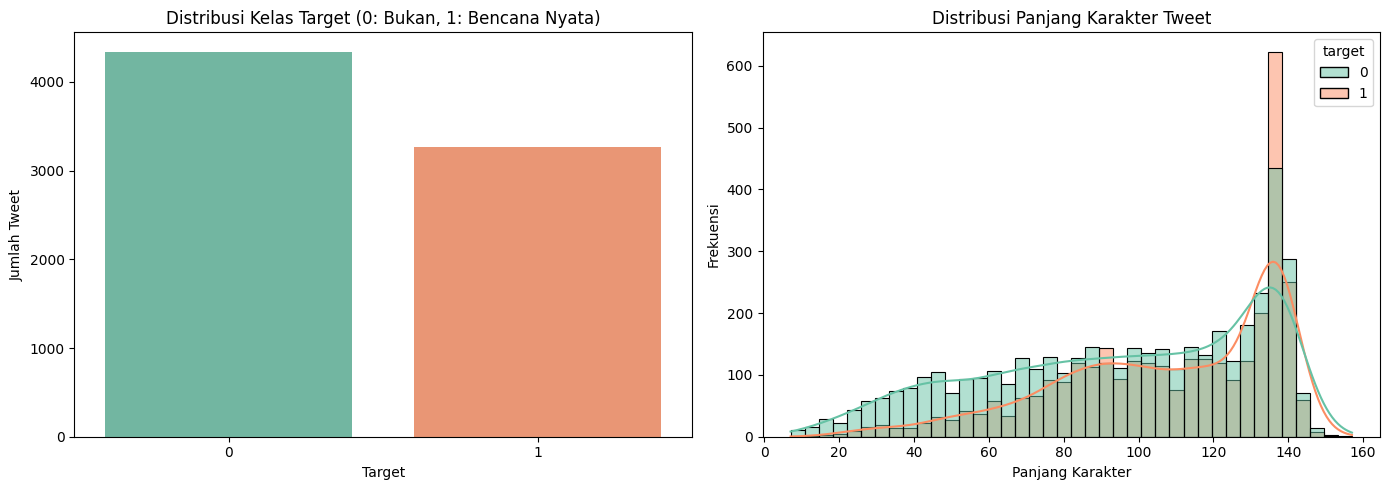

In [2]:
# TAHAP 2: EKSPLORASI DATA (EDA)


plt.figure(figsize=(14, 5))

# Visualisasi 1: Distribusi Target (Bencana vs Bukan Bencana)
plt.subplot(1, 2, 1)
sns.countplot(x='target', data=df, palette='Set2')
plt.title('Distribusi Kelas Target (0: Bukan, 1: Bencana Nyata)')
plt.xlabel('Target')
plt.ylabel('Jumlah Tweet')

# Visualisasi 2: Distribusi Panjang Karakter Tweet berdasarkan Target
# Untuk melihat apakah tweet bencana cenderung lebih panjang/pendek
df['char_length'] = df['text'].str.len()
plt.subplot(1, 2, 2)
sns.histplot(data=df, x='char_length', hue='target', kde=True, palette='Set2', bins=40)
plt.title('Distribusi Panjang Karakter Tweet')
plt.xlabel('Panjang Karakter')
plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()

# Hapus kolom char_length karena hanya untuk EDA
df = df.drop(columns=['char_length'])

Preprocessing

In [3]:
# TAHAP 3: PREPROCESSING & DATA SPLIT


# Fungsi untuk membersihkan teks dari noise (lowercasing, hapus URL, mention, dll)
def clean_text(text):
    text = text.lower() # Lowercasing
    text = re.sub(r'http\S+|www\.\S+', '', text) # Hapus URL
    text = re.sub(r'@\w+', '', text) # Hapus Mention
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Hapus Tanda Baca/Karakter Spesial
    # Hapus Stopwords (meningkatkan kualitas TF-IDF agar fokus pada kata penting)
    text = " ".join([word for word in text.split() if word not in stop_words])
    return text

# Aplikasikan fungsi pembersihan ke seluruh dataset
print("Memulai proses pembersihan teks...")
df['clean_text'] = df['text'].apply(clean_text)

# Train-Validation Split (80% Data Latih, 20% Data Validasi)
X_train, X_val, y_train, y_val = train_test_split(df['clean_text'], df['target'], test_size=0.2, random_state=42)

print("Preprocessing selesai! Contoh teks bersih:")
display(X_train.head(3))

Memulai proses pembersihan teks...
Preprocessing selesai! Contoh teks bersih:


,clean_text
4996,courageous honest analysis need use atomic bom...
3263,wld b shame golf cart became engulfed flames b...
4907,tell rescind medals honor given us soldiers ma...


Metode Konvensional (TF-IDF + LR & TF-IDF + NB)

In [4]:
# TAHAP 4: PELATIHAN MODEL KONVENSIONAL


# Vektorisasi Teks menggunakan TF-IDF (Unigram & Bigram)
# Mengubah teks menjadi representasi angka berdasarkan frekuensi kemunculan kata
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)

# --- Kombinasi 1: TF-IDF + Logistic Regression ---
lr_model = LogisticRegression(random_state=42, max_iter=1000)

start_time = time.time()
lr_model.fit(X_train_tfidf, y_train)
lr_train_time = time.time() - start_time

lr_pred = lr_model.predict(X_val_tfidf)
lr_f1 = f1_score(y_val, lr_pred)

print(f"=== TF-IDF + LOGISTIC REGRESSION ===")
print(f"F1-Score      : {lr_f1:.4f}")
print(f"Waktu Training: {lr_train_time:.4f} detik\n")


# --- Kombinasi 2: TF-IDF + Multinomial Naive Bayes ---
nb_model = MultinomialNB()

start_time = time.time()
nb_model.fit(X_train_tfidf, y_train)
nb_train_time = time.time() - start_time

nb_pred = nb_model.predict(X_val_tfidf)
nb_f1 = f1_score(y_val, nb_pred)

print(f"=== TF-IDF + NAIVE BAYES ===")
print(f"F1-Score      : {nb_f1:.4f}")
print(f"Waktu Training: {nb_train_time:.4f} detik")

=== TF-IDF + LOGISTIC REGRESSION ===
F1-Score      : 0.7531
Waktu Training: 0.1219 detik

=== TF-IDF + NAIVE BAYES ===
F1-Score      : 0.7400
Waktu Training: 0.0083 detik


Model Deep Learning (BiLSTM)

In [5]:
# TAHAP 5: PELATIHAN DEEP LEARNING (BiLSTM)


# Parameter Tokenizer & Padding
MAX_WORDS = 10000 # Batas kosa kata maksimal
MAX_LEN = 50      # Batas panjang kata per kalimat

# Tokenisasi & Padding (Mengubah teks menjadi sekuens integer dan menyeragamkan panjang)
tokenizer = Tokenizer(num_words=MAX_WORDS)
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN)
X_val_seq = pad_sequences(tokenizer.texts_to_sequences(X_val), maxlen=MAX_LEN)

# Membangun Arsitektur BiLSTM (Bidirectional LSTM)
# Justifikasi: BiLSTM mampu membaca teks secara dua arah untuk memahami konteks semantik penuh
dl_model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5), # Regularisasi
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid') # Biner: 0 atau 1
])

# Kompilasi model
dl_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Menyematkan Early Stopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Training Model
print("Memulai proses training model BiLSTM...\n")
start_time = time.time()
history = dl_model.fit(X_train_seq, y_train,
                       epochs=10,
                       batch_size=64,
                       validation_data=(X_val_seq, y_val),
                       callbacks=[early_stop],
                       verbose=1)
dl_train_time = time.time() - start_time

# Prediksi & Evaluasi F1-Score
dl_prob = dl_model.predict(X_val_seq)
dl_pred = (dl_prob > 0.5).astype(int).reshape(-1)
dl_f1 = f1_score(y_val, dl_pred)

print(f"\n=== DEEP LEARNING (BiLSTM) ===")
print(f"F1-Score      : {dl_f1:.4f}")
print(f"Waktu Training: {dl_train_time:.4f} detik")
print("==============================\n")

dl_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Memulai proses training model BiLSTM...

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 22s 149ms/step - accuracy: 0.6437 - loss: 0.6266 - val_accuracy: 0.7932 - val_loss: 0.4582
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 25s 199ms/step - accuracy: 0.8514 - loss: 0.3659 - val_accuracy: 0.7873 - val_loss: 0.5355
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 13s 138ms/step - accuracy: 0.9174 - loss: 0.2344 - val_accuracy: 0.7741 - val_loss: 0.6663
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 19s 125ms/step - accuracy: 0.9470 - loss: 0.1635 - val_accuracy: 0.7603 - val_loss: 0.7580
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step

=== DEEP LEARNING (BiLSTM) ===
F1-Score      : 0.7364
Waktu Training: 80.4001 detik



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,148,933 (15.83 MB)

 Trainable params: 1,382,977 (5.28 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,765,956 (10.55 MB)

Evaluasi & Analisis Error

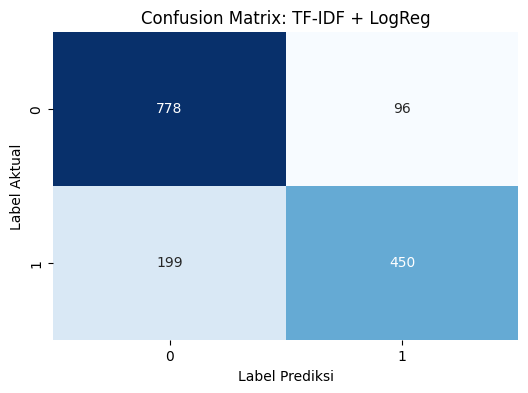

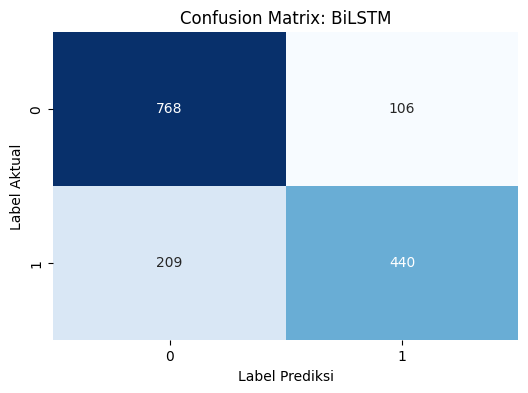

=== CONTOH ERROR ANALYSIS ===
Kasus di mana Deep Learning (BiLSTM) lebih memahami konteks daripada TF-IDF:

Teks Asli        : Dear @CanonUSAimaging I brought it ;) #CanonBringIt #Fire  #CanonTattoo #MN #TheresMoreWhereThatCameFrom http://t.co/tCXxHdJAs6
Status Sebenarnya: BUKAN BENCANA (0)
Prediksi TF-IDF  : 1 (SALAH)
Prediksi BiLSTM  : 0 (BENAR)
------------------------------------------------------------
Teks Asli        : Magic City Mayhem: Kissimmee adventures ? Aug. 5 2015 http://t.co/FpYrU5GOLh
Status Sebenarnya: BUKAN BENCANA (0)
Prediksi TF-IDF  : 1 (SALAH)
Prediksi BiLSTM  : 0 (BENAR)
------------------------------------------------------------
Teks Asli        : Oh shit its rly sheeting
Aaaaaand there's the thunder and lightning
I missed summer storms
Status Sebenarnya: BENCANA NYATA (1)
Prediksi TF-IDF  : 0 (SALAH)
Prediksi BiLSTM  : 1 (BENAR)
------------------------------------------------------------


In [6]:
# TAHAP 6: ANALISIS KESALAHAN (ERROR ANALYSIS)

# 1. Menampilkan Confusion Matrix
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(title)
    plt.xlabel('Label Prediksi')
    plt.ylabel('Label Aktual')
    plt.show()

plot_cm(y_val, lr_pred, 'Confusion Matrix: TF-IDF + LogReg')
plot_cm(y_val, dl_pred, 'Confusion Matrix: BiLSTM')

# 2. Analisis Konteks (Mencari di mana DL menangkap konteks yang gagal dipahami TF-IDF)
val_df = pd.DataFrame({
    'text': df.loc[y_val.index, 'text'],
    'true_label': y_val,
    'lr_pred': lr_pred,
    'dl_pred': dl_pred
})

# Filter kasus di mana TF-IDF salah (False Positive/Negative), tapi BiLSTM benar
dl_better = val_df[(val_df['lr_pred'] != val_df['true_label']) & (val_df['dl_pred'] == val_df['true_label'])]

print("=== CONTOH ERROR ANALYSIS ===")
print("Kasus di mana Deep Learning (BiLSTM) lebih memahami konteks daripada TF-IDF:\n")
for idx, row in dl_better.head(3).iterrows():
    label_str = "BENCANA NYATA (1)" if row['true_label'] == 1 else "BUKAN BENCANA (0)"
    print(f"Teks Asli        : {row['text']}")
    print(f"Status Sebenarnya: {label_str}")
    print(f"Prediksi TF-IDF  : {row['lr_pred']} (SALAH)")
    print(f"Prediksi BiLSTM  : {row['dl_pred']} (BENAR)")
    print("-" * 60)